In [57]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report
from sklearn.linear_model import RidgeCV
from sklearn.metrics import f1_score
from sklearn.metrics import pairwise_distances

from sklearn.linear_model import LinearRegression



# Loading Data

In [19]:
from calendar import month


with np.load("../../outputs/segmented_embeddings/siglip2-so400m-14-384_clahe_embeddings.npz") as data:
    emb = data["features"]
    age = data["labels"]
    meId = data["measurement_ids"]

meta = pd.read_csv("../../cod_otolith_age_final_with_scale.csv")[[
    "measurement_id",
    "age", "length",
    "month", "month_cos", "month_sin",
    "seg_width_px",
    "seg_height_px",
    "seg_aspect_ratio",
    ]]

meta = meta[meta["measurement_id"].isin(meId)]

# Align meta to embedding order
meta_aligned = (
    pd.DataFrame({'measurement_id': meId})
    .merge(meta, on='measurement_id', how='left')
)

# Verify alignment
assert len(meta_aligned) == len(emb), "Row count mismatch"
assert (meta_aligned['measurement_id'].values == meId).all(), "ID order mismatch"

# Now these are safe to use in parallel with emb and age
length   = meta_aligned['length'].values
month_sin    = meta_aligned['month_sin'].values
month_cos    = meta_aligned['month_cos'].values
month      = meta_aligned['month'].values
seg_w    = meta_aligned['seg_width_px'].values
seg_h    = meta_aligned['seg_height_px'].values
aspect_ratio = meta_aligned['seg_aspect_ratio'].values

X_train, X_test, y_train, y_test = train_test_split(
    emb, age, test_size=0.15, random_state=81, stratify=age
)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Embedding shapes:", emb.shape, "\nAge shapes:", age.shape)


Embedding shapes: (8619, 1152) 
Age shapes: (8619,)


# Maturity Axis (fit to min max age)


In [6]:
# Identify extreme ages
unique_ages = np.unique(age)
min_age, max_age = min(unique_ages), max(unique_ages)
print(f"Unique ages: {unique_ages}")

Unique ages: [ 1  2  3  4  5  6  7  8  9 10]


In [ ]:
# Calculate Prototypes
proto_young = np.mean(emb[age == min_age], axis=0)
proto_old = np.mean(emb[age == max_age], axis=0)

# Define the Age Direction Vector (normalized)
age_direction = proto_old-proto_young
age_direction = age_direction / np.linalg.norm(age_direction)

# Projection of ALL the embeddings in this axis
## Dot product between each embeddding and the direction vector
projections = np.dot(emb, age_direction)

# Calculate the Residuals (To remove the age component)
# residuals = original - (projection * direction vec.)
age_components = np.outer(projections, age_direction)
res = emb - age_components




In [64]:
# Validate signal: Average of real scores per real group

print("Average Projection per Real Age:")
for a in np.unique(age):
    mean_proj = projections[age == a].mean()
    print(f"Age {a}: {mean_proj:.4f}")


Average Projection per Real Age:
Age 1: 0.0333
Age 2: 0.0451
Age 3: 0.0599
Age 4: 0.0674
Age 5: 0.0715
Age 6: 0.0748
Age 7: 0.0779
Age 8: 0.0829
Age 9: 0.0847
Age 10: 0.0896


/var/folders/yy/91yd99zj55qfx3v8d5xn2htm0000gp/T/ipykernel_26180/3968246982.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=age_scores, palette="viridis")


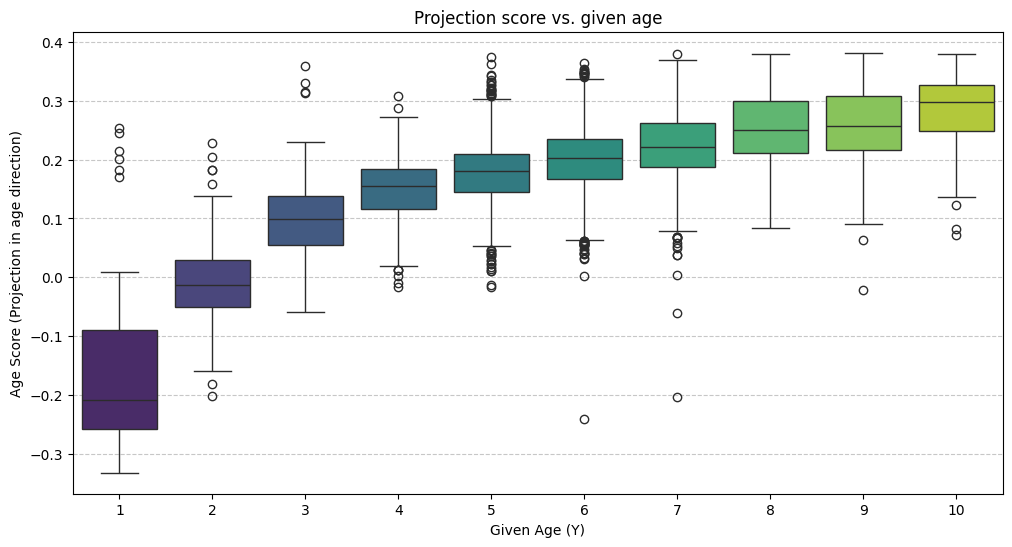

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_age_distribution(age_scores, labels):
    plt.figure(figsize=(12, 6))

    # Criar o Boxplot com um Swarmplot por cima (opcional, para ver a densidade)
    sns.boxplot(x=labels, y=age_scores, palette="viridis")

    plt.title("Projection score vs. given age")
    plt.xlabel("Given Age (Y)")
    plt.ylabel("Age Score (Projection in age direction)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Usar os scores que calculaste antes
plot_age_distribution(projections, age)


# Plotting Residuals

/opt/miniconda3/envs/oto-cod-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/miniconda3/envs/oto-cod-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/miniconda3/envs/oto-cod-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


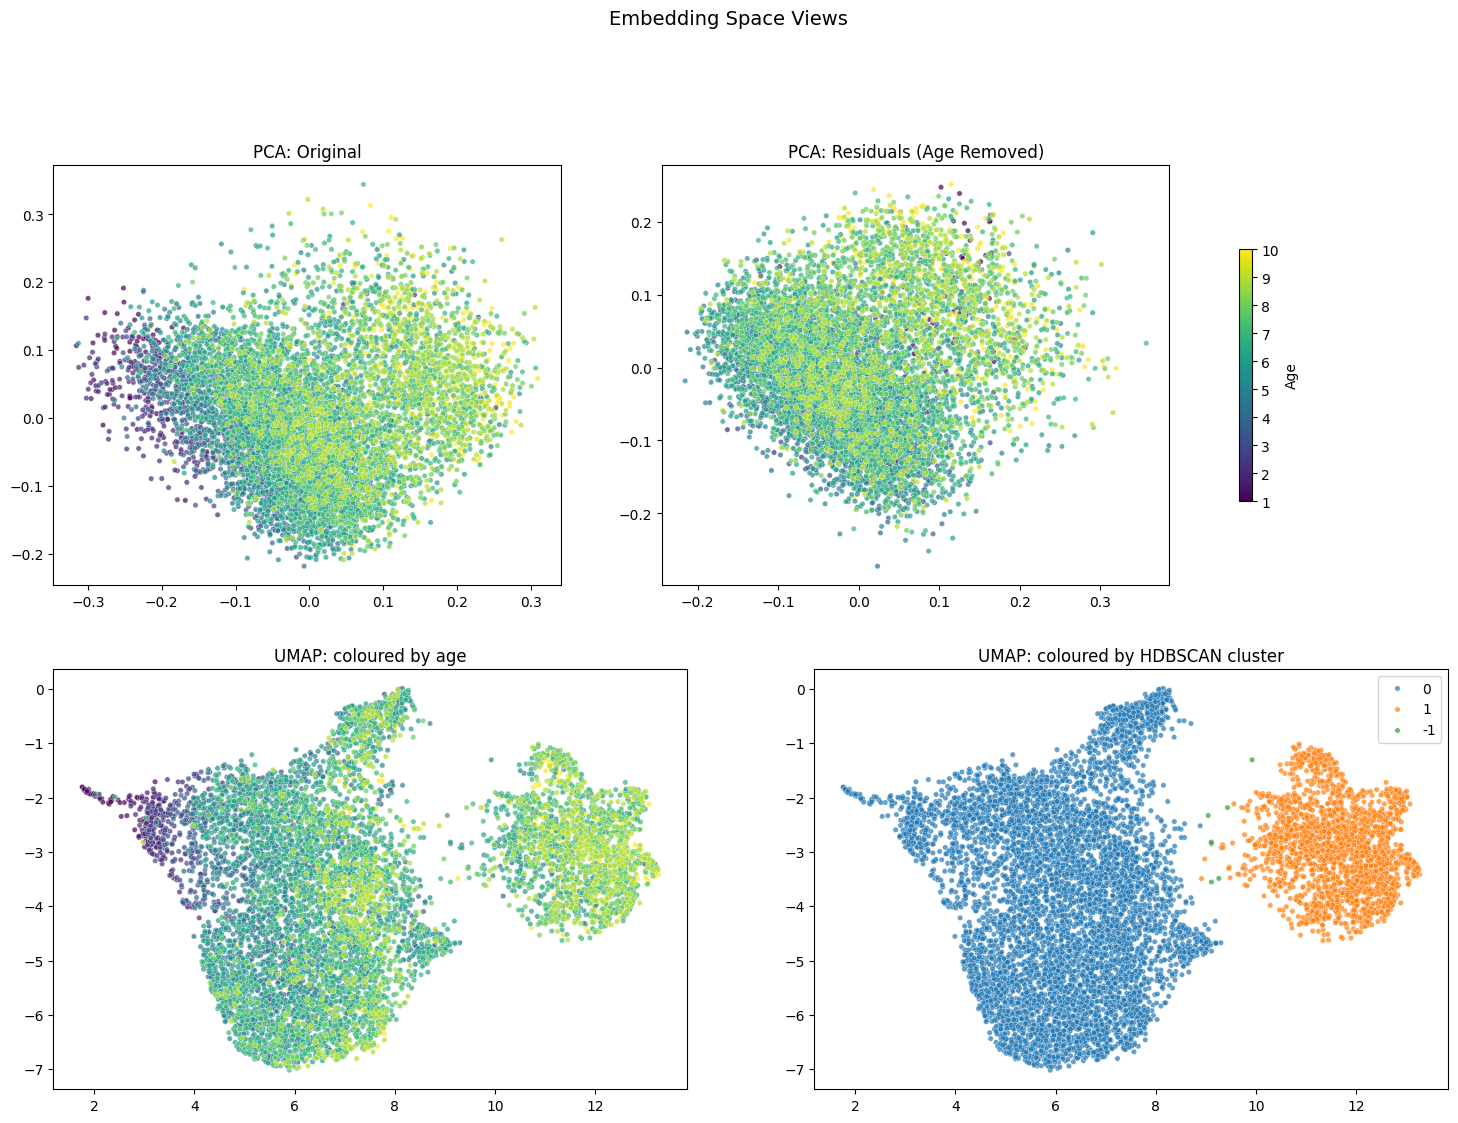

Cluster -1: n=7, mean age=6.57, median age=6.0
Cluster 0: n=6571, mean age=5.69, median age=6.0
Cluster 1: n=2041, mean age=7.74, median age=8.0


In [11]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap
import hdbscan
import seaborn as sns
import numpy as np

def plot_embedding_views(original_emb, residuals, labels):
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.flatten()

    umap_2d = umap.UMAP(n_components=2, metric="cosine",
                         n_neighbors=30, min_dist=0.1,
                         random_state=42).fit_transform(original_emb)

    clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10)
    cluster_labels = clusterer.fit_predict(umap_2d)

    pca_orig = PCA(n_components=2).fit_transform(original_emb)
    pca_res  = PCA(n_components=2).fit_transform(residuals)

    configs = [
        ("PCA: Original",                  pca_orig,  "age"),
        ("PCA: Residuals (Age Removed)",   pca_res,   "age"),
        ("UMAP: coloured by age",          umap_2d,   "age"),
        ("UMAP: coloured by HDBSCAN cluster", umap_2d, "cluster"),
    ]

    for ax, (title, X_2d, colour_by) in zip(axes, configs):
        if colour_by == "cluster":
            sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1],
                            hue=cluster_labels.astype(str),
                            palette="tab10", ax=ax, s=15, alpha=0.7)
        else:
            sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1],
                            hue=labels, palette="viridis",
                            ax=ax, s=15, alpha=0.7, legend=False)
        ax.set_title(title)

    sm = plt.cm.ScalarMappable(cmap="viridis",
                                norm=plt.Normalize(vmin=min(labels),
                                                   vmax=max(labels)))
    fig.colorbar(sm, ax=axes[:2], label="Age", shrink=0.6)
    plt.suptitle("Embedding Space Views", fontsize=14, y=1.01)
    
    plt.show()

    for c in np.unique(cluster_labels):
        mask = cluster_labels == c
        print(f"Cluster {c}: n={mask.sum()}, "
              f"mean age={labels[mask].mean():.2f}, "
              f"median age={np.median(labels[mask]):.1f}")

    return cluster_labels

cluster_labels = plot_embedding_views(emb, res, age)

            age                                                length  \
          count      mean       std  min  25%  50%  75%   max   count   
cluster                                                                 
-1          7.0  6.571429  1.988060  4.0  5.5  6.0  7.5  10.0     7.0   
 0       6571.0  5.690306  1.785651  1.0  5.0  6.0  7.0  10.0  6571.0   
 1       2041.0  7.735424  1.519663  1.0  7.0  8.0  9.0  10.0  2041.0   

                    ...    aspect             area                 \
              mean  ...       75%      max   count           mean   
cluster             ...                                             
-1       76.571429  ...  329.3090  371.448     7.0  310901.714286   
 0       63.001978  ...  279.6625  397.032  6571.0  224425.516055   
 1       85.153356  ...  428.6700  730.422  2041.0  388783.167075   

                                                                         
                  std       min       25%       50%       75%       max 

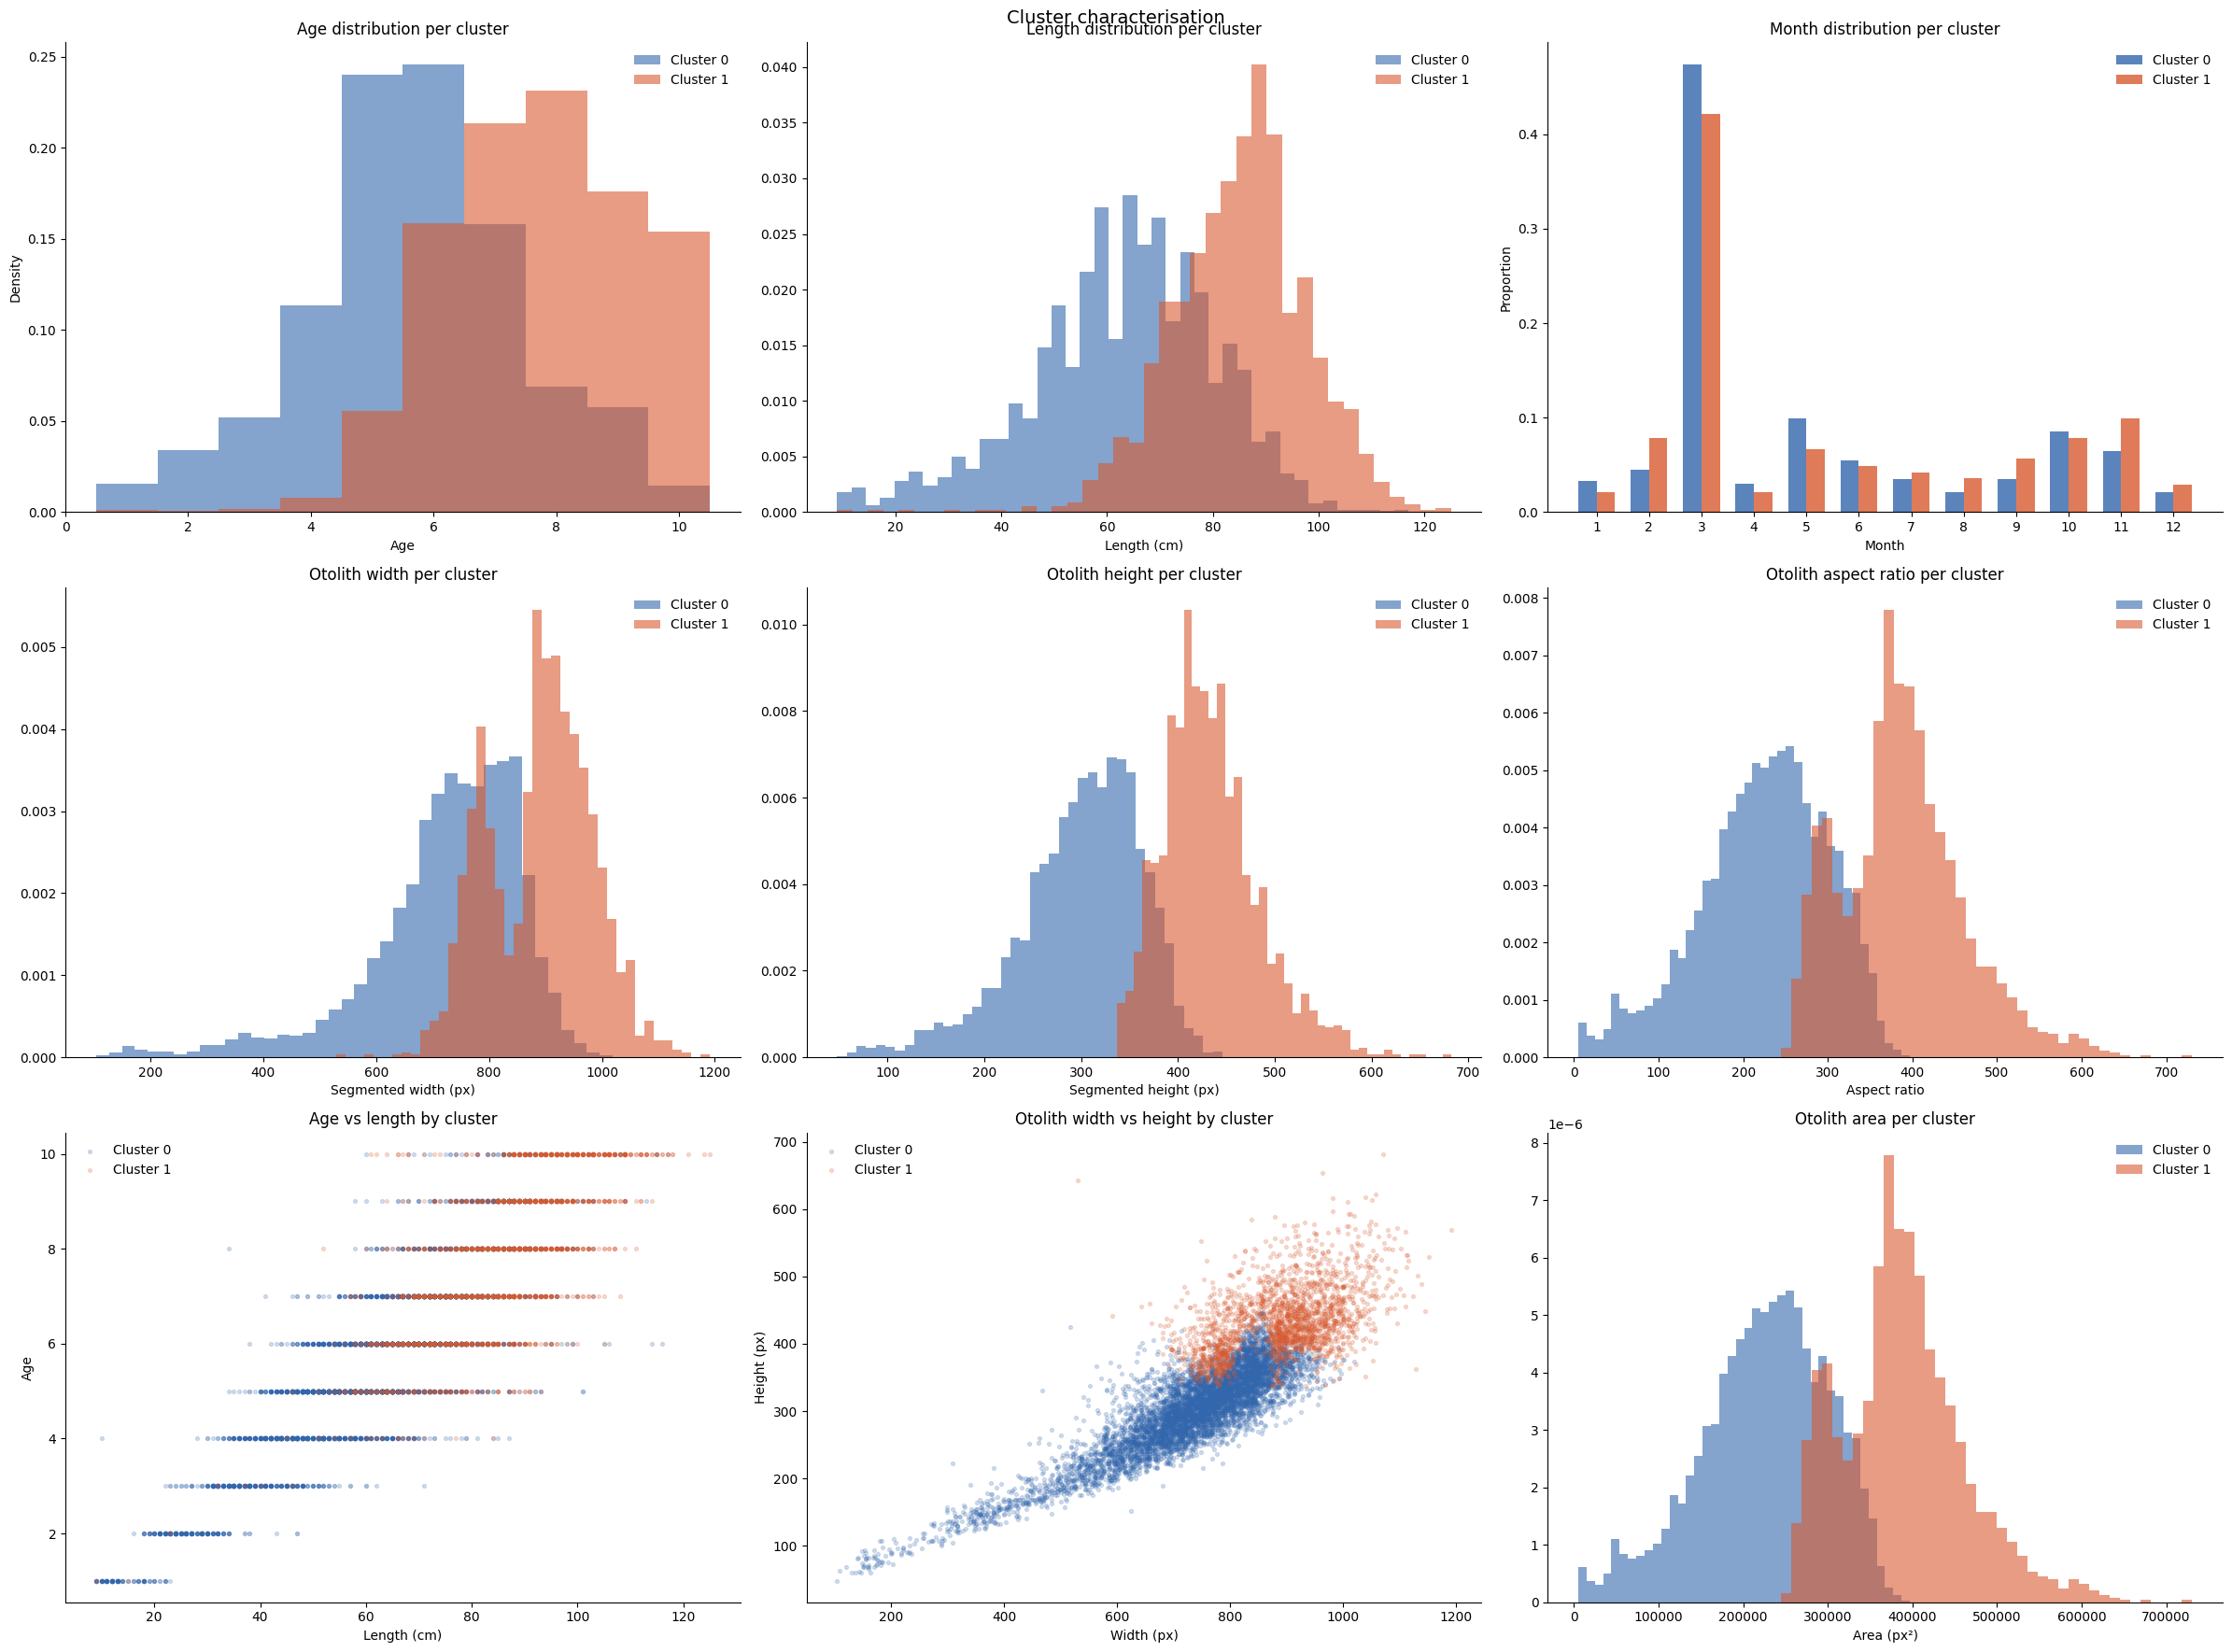

In [56]:
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame({
    'cluster':  cluster_labels,
    'age':      age,
    'length':   length,
    'month':    month,
    'seg_width': seg_w,
    'seg_height': seg_h,
}).assign(aspect=meta_aligned['seg_aspect_ratio'].values)

df['area'] = df['seg_width'] * df['seg_height']

print(df.groupby('cluster')[['age', 'length', 'seg_width', 'aspect', "area"]].describe())
print("\nMonth distribution per cluster:")
print(df.groupby('cluster')['month'].value_counts().unstack().fillna(0))

fig, axes = plt.subplots(3, 3, figsize=(24, 18))
axes = axes.flatten()

# 1. Age
ax = axes[0]
for c, color in zip([0, 1], ['#3266ad', '#D85A30']):
    mask = df['cluster'] == c
    ax.hist(df.loc[mask, 'age'], bins=np.arange(0.5, 11.5, 1),
            alpha=0.6, color=color, label=f'Cluster {c}', density=True)
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.set_title('Age distribution per cluster')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# 2. Length
ax = axes[1]
for c, color in zip([0, 1], ['#3266ad', '#D85A30']):
    mask = df['cluster'] == c
    ax.hist(df.loc[mask, 'length'].dropna(), bins=40,
            alpha=0.6, color=color, label=f'Cluster {c}', density=True)
ax.set_xlabel('Length (cm)')
ax.set_title('Length distribution per cluster')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# 3. Month
ax = axes[2]
months = np.arange(1, 13)
w = 0.35
for i, (c, color) in enumerate(zip([0, 1], ['#3266ad', '#D85A30'])):
    mask = df['cluster'] == c
    counts = df.loc[mask, 'month'].value_counts().reindex(months, fill_value=0)
    counts = counts / counts.sum()
    ax.bar(months + i * w - w/2, counts, width=w,
           color=color, alpha=0.8, label=f'Cluster {c}')
ax.set_xlabel('Month')
ax.set_ylabel('Proportion')
ax.set_title('Month distribution per cluster')
ax.set_xticks(months)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# 4. Seg width
ax = axes[3]
for c, color in zip([0, 1], ['#3266ad', '#D85A30']):
    mask = df['cluster'] == c
    ax.hist(df.loc[mask, 'seg_width'].dropna(), bins=40,
            alpha=0.6, color=color, label=f'Cluster {c}', density=True)
ax.set_xlabel('Segmented width (px)')
ax.set_title('Otolith width per cluster')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# 5. Seg height
ax = axes[4]
for c, color in zip([0, 1], ['#3266ad', '#D85A30']):
    mask = df['cluster'] == c
    ax.hist(df.loc[mask, 'seg_height'].dropna(), bins=40,
            alpha=0.6, color=color, label=f'Cluster {c}', density=True)
ax.set_xlabel('Segmented height (px)')
ax.set_title('Otolith height per cluster')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# 6. Aspect ratio
ax = axes[5]
for c, color in zip([0, 1], ['#3266ad', '#D85A30']):
    mask = df['cluster'] == c
    ax.hist(df.loc[mask, 'aspect'].dropna(), bins=40,
            alpha=0.6, color=color, label=f'Cluster {c}', density=True)
ax.set_xlabel('Aspect ratio')
ax.set_title('Otolith aspect ratio per cluster')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# 7. Age vs length scatter
ax = axes[6]
for c, color in zip([0, 1], ['#3266ad', '#D85A30']):
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask, 'length'], df.loc[mask, 'age'],
               color=color, alpha=0.2, s=8, label=f'Cluster {c}')
ax.set_xlabel('Length (cm)')
ax.set_ylabel('Age')
ax.set_title('Age vs length by cluster')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# 8. Width vs height scatter
ax = axes[7]
for c, color in zip([0, 1], ['#3266ad', '#D85A30']):
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask, 'seg_width'], df.loc[mask, 'seg_height'],
               color=color, alpha=0.2, s=8, label=f'Cluster {c}')
ax.set_xlabel('Width (px)')
ax.set_ylabel('Height (px)')
ax.set_title('Otolith width vs height by cluster')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)


# 9. Otolith area
ax = axes[8]
ax.hist(df.loc[df['cluster']==0, 'area'], bins=40, alpha=0.6, color='#3266ad', label='Cluster 0', density=True)
ax.hist(df.loc[df['cluster']==1, 'area'], bins=40, alpha=0.6, color='#D85A30', label='Cluster 1', density=True)
ax.set_xlabel('Area (px²)')
ax.set_title('Otolith area per cluster')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)


plt.suptitle('Cluster characterisation', fontsize=14)
plt.tight_layout()
plt.savefig('cluster_characterisation.png', dpi=150, bbox_inches='tight')
plt.show()

In [55]:
print(type(axes[8]))
print(axes[8].get_position())

<class 'matplotlib.axes._axes.Axes'>
Bbox(x0=0.6894907407407407, y0=0.032376543209876374, x1=0.9891666666666665, y1=0.3118518518518517)


Text(0, 0.5, 'Area (px²)')

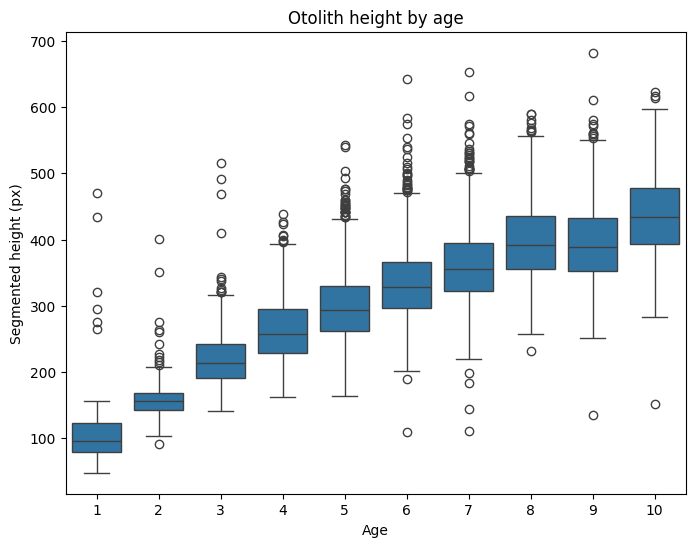

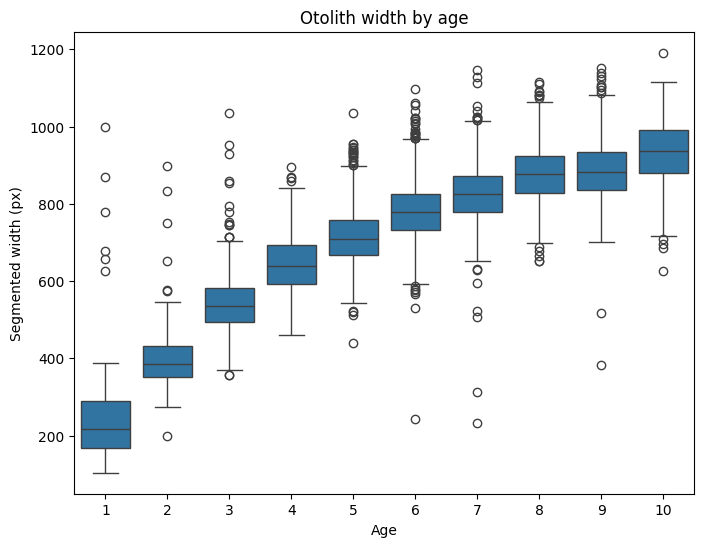

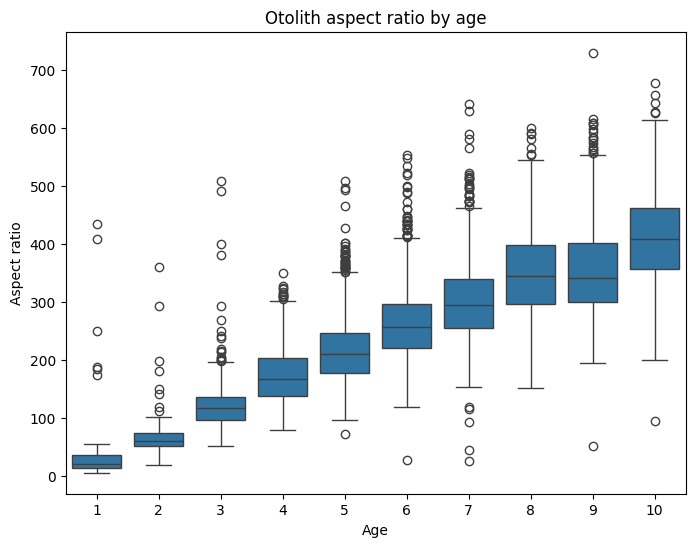

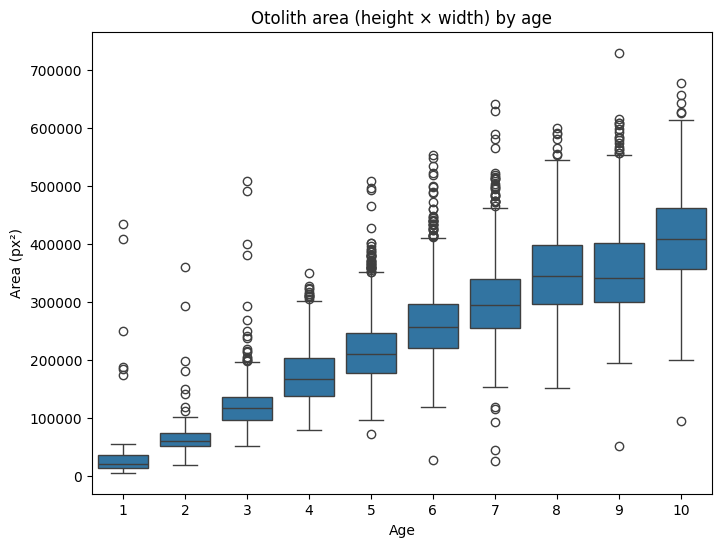

In [41]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['seg_height'], x=df['age'])
plt.title('Otolith height by age')
plt.xlabel('Age')
plt.ylabel('Segmented height (px)')

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['seg_width'], x=df['age'])
plt.title('Otolith width by age')
plt.xlabel('Age')
plt.ylabel('Segmented width (px)')

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['aspect'], x=df['age'])
plt.title('Otolith aspect ratio by age')
plt.xlabel('Age')
plt.ylabel('Aspect ratio')

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['seg_height'] * df['seg_width'], x=df['age'])
plt.title('Otolith area (height × width) by age')
plt.xlabel('Age')
plt.ylabel('Area (px²)')






# Residualize Otolith Height

In [124]:
# Reshape and fit linear regression to predict each embedding feature from height
seg_h = seg_h.reshape(-1, 1)  # Reshape to (n_samples, 1) for sklearn
seg_w = seg_w.reshape(-1, 1)  # Reshape width as well if you want to include it
area = (seg_h * seg_w).reshape(-1, 1)  # Calculate area and reshape
aspect_ratio = aspect_ratio.reshape(-1, 1)  # Reshape aspect ratio

size = np.hstack([seg_w, seg_h, area, aspect_ratio])  # Combine width, height, and area into a single feature matrix
reg = LinearRegression().fit(size, emb)


# Height prediction for each embedding feature
emb_pred = reg.predict(size)

# The residuals = actual - predicted
res_res = emb - emb_pred



## Age axis for Height Residualized Feat

In [121]:
# Identify extreme ages
unique_ages = np.unique(age)
min_age, max_age = min(unique_ages), max(unique_ages)
print(f"Unique ages: {unique_ages}")

Unique ages: [ 1  2  3  4  5  6  7  8  9 10]


In [125]:
# Calculate Prototypes
proto_young = np.mean(res_res[age == min_age], axis=0)
proto_old = np.mean(res_res[age == max_age], axis=0)

# Define the Age Direction Vector (normalized)
age_direction = proto_old-proto_young
age_direction = age_direction / np.linalg.norm(age_direction)

# Projection of ALL the embeddings in this axis
## Dot product between each embeddding and the direction vector
projections = np.dot(emb, age_direction)

# Calculate the Residuals (To remove the size component)
# residuals = original - (projection * direction vec.)
age_components = np.outer(projections, age_direction)
res = emb - age_components


# Validate signal: Average of real scores per real group

print("Average Projection per Real Age:")
for a in np.unique(age):
    mean_proj = projections[age == a].mean()
    print(f"Age {a}: {mean_proj:.4f}")


Average Projection per Real Age:
Age 1: -0.0244
Age 2: 0.1847
Age 3: 0.1904
Age 4: 0.1700
Age 5: 0.1598
Age 6: 0.1521
Age 7: 0.1544
Age 8: 0.1606
Age 9: 0.1659
Age 10: 0.1811


/var/folders/yy/91yd99zj55qfx3v8d5xn2htm0000gp/T/ipykernel_26180/3968246982.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=age_scores, palette="viridis")


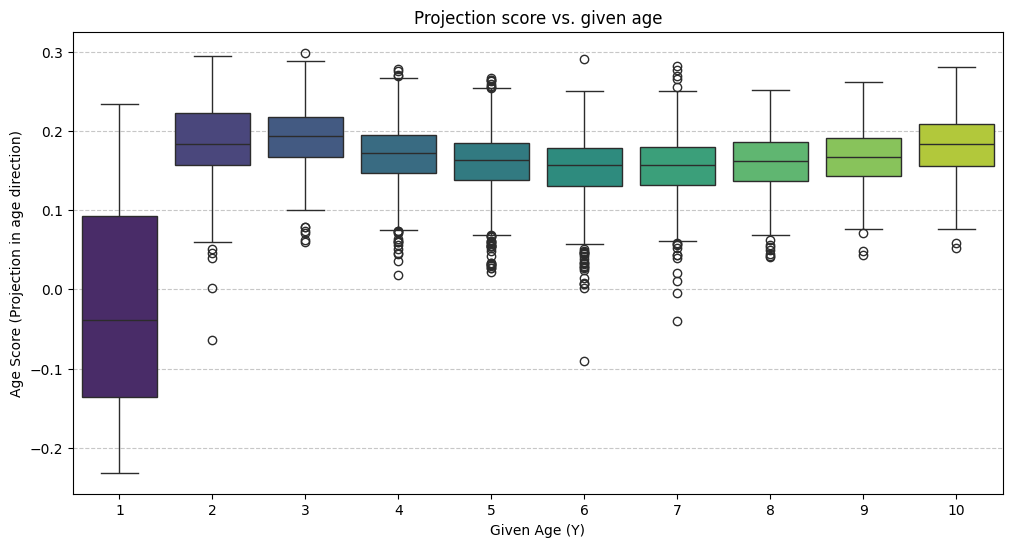

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_age_distribution(age_scores, labels):
    plt.figure(figsize=(12, 6))

    # Criar o Boxplot com um Swarmplot por cima (opcional, para ver a densidade)
    sns.boxplot(x=labels, y=age_scores, palette="viridis")

    plt.title("Projection score vs. given age")
    plt.xlabel("Given Age (Y)")
    plt.ylabel("Age Score (Projection in age direction)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Usar os scores que calculaste antes
plot_age_distribution(projections, age)


/opt/miniconda3/envs/oto-cod-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/miniconda3/envs/oto-cod-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


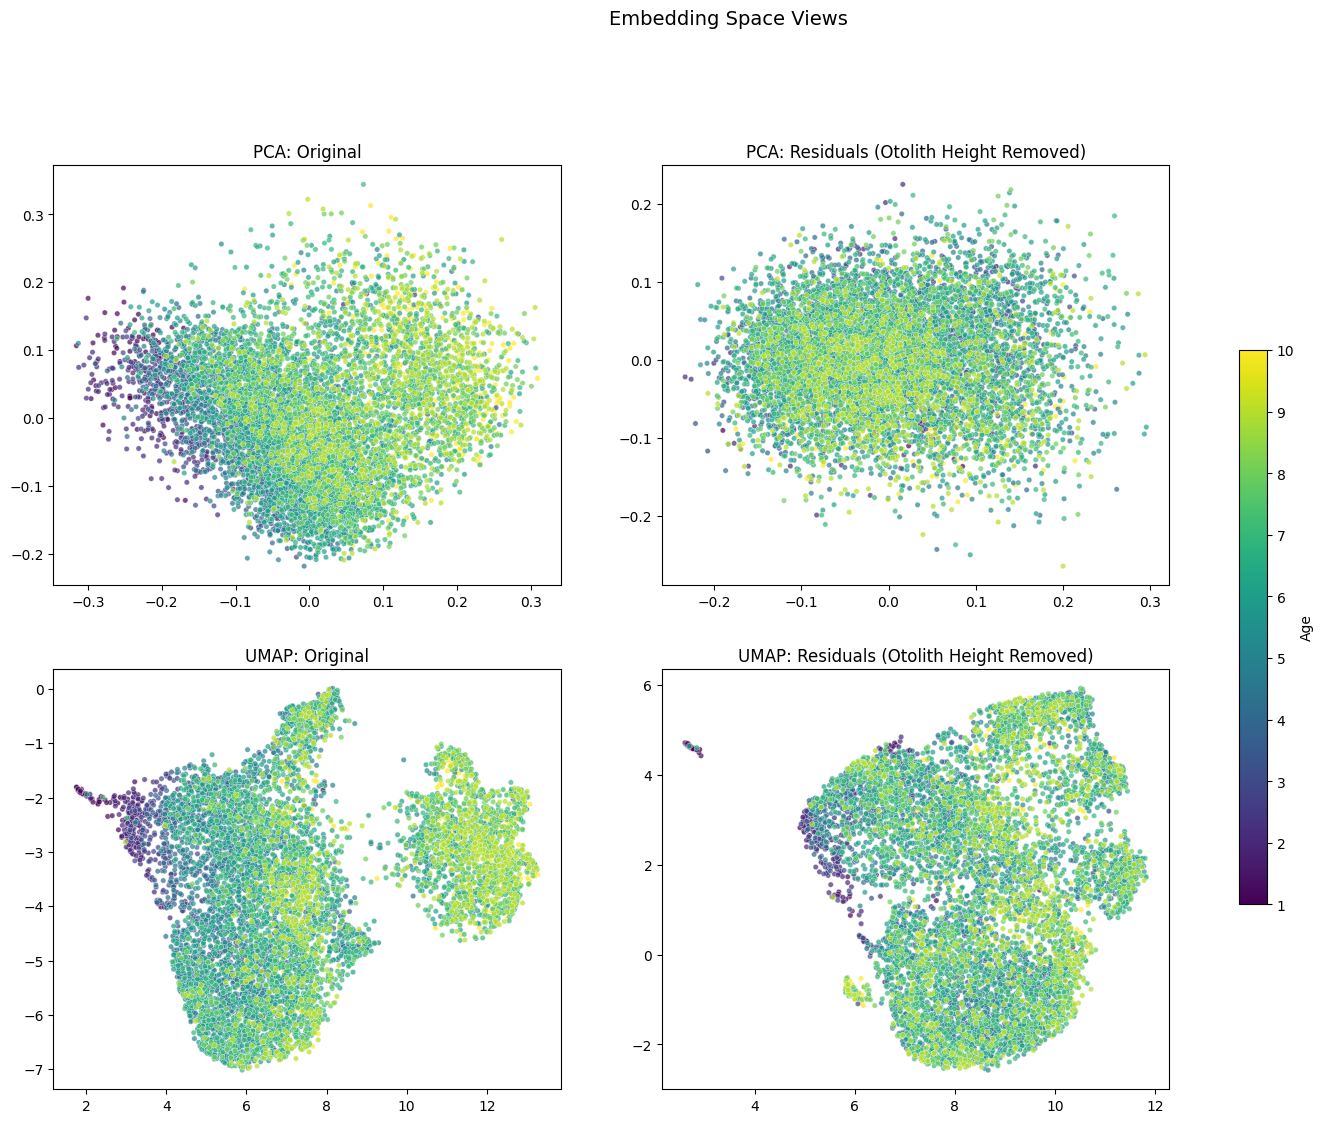

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap
import seaborn as sns
import numpy as np

def plot_embedding_views(original_emb, residuals, labels):
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.flatten()

    umap_orig = umap.UMAP(n_components=2, metric="cosine",
                          n_neighbors=30, min_dist=0.1,
                          random_state=42).fit_transform(original_emb)

    umap_res = umap.UMAP(n_components=2, metric="cosine",
                         n_neighbors=30, min_dist=0.1,
                         random_state=42).fit_transform(residuals)

    pca_orig = PCA(n_components=2).fit_transform(original_emb)
    pca_res  = PCA(n_components=2).fit_transform(residuals)

    configs = [
        ("PCA: Original",                            pca_orig,  ),
        ("PCA: Residuals (Otolith Size Removed)",  pca_res,   ),
        ("UMAP: Original",                           umap_orig, ),
        ("UMAP: Residuals (Otolith Size Removed)", umap_res,  ),
    ]

    for ax, (title, X_2d) in zip(axes, configs):
        sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1],
                        hue=labels, palette="viridis",
                        ax=ax, s=15, alpha=0.7, legend=False)
        ax.set_title(title)

    sm = plt.cm.ScalarMappable(cmap="viridis",
                                norm=plt.Normalize(vmin=min(labels),
                                                   vmax=max(labels)))
    fig.colorbar(sm, ax=axes, label="Age", shrink=0.6)
    plt.suptitle("Embedding Space Views", fontsize=14, y=1.01)
    
    plt.show()

plot_embedding_views(emb, res_res, age)

# Performance evaluation

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import RidgeCV

# Get residials 
X = res_res  

sss = StratifiedShuffleSplit(n_splits=10, test_size=0.15, random_state=42)

for train_index, test_index in sss.split(X, age):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = age[train_index], age[test_index]

    model = RidgeCV(alphas=np.logspace(-2, 3, 30), store_cv_values=True)
    model.fit(X_train, y_train)

print(f"{X_train.shape=}, {y_train.shape=}, {X_test.shape=}, {y_test.shape=}")


X_train.shape=(7326, 1152), y_train.shape=(7326,), X_test.shape=(1293, 1152), y_test.shape=(1293,)


In [ ]:
for i 